## Random Seed Sensitivity:
Goal: Assess how sensitive the model’s performance is to different random initializations by training with multiple seeds

Procedure:
1. Train the best configuration from 1c with multiple seeds: [0, 42, 1234, 67, 619]
2. Test using the testing data by doing a "forecast_rollout"
3. Calculate the average and the std division of the global RMSE calculated from these runs

Results:
- Average Global RMSE: 5.63
- Standard Deviation: 0.43
The variation is about 7.6% of the average value, indicating low variability and stability across different seeds


In [1]:
from utils.utils import VarSet, DataSet
from architectures.cnn_baseline import CNN2D, set_seed, Results

set_seed()
t_ref = VarSet(
    var_name="t_ref",
    file_name="PP_DATA/t_ref.192101-201012.nc",
    is_output=True
)

spatial_features = VarSet(
    var_name="spatial_features",
    file_name="PP_DATA/spatial_features.nc",
    is_static=True
)

variables = [t_ref, spatial_features]
data = DataSet(set_name="set1", variables=variables)
lon, lat = t_ref.get_grid()
time_test = t_ref.get_time('time_test')

In [ ]:
nepochs = 50

Learning_Rate = 0.00016536937182824412
Layers = [64, 128, 128]
Batch_Size = 32
Optimizer = "AdamW"
Weight_Decay = 0.00012030178871154674

seeds = [0, 42, 1234, 67, 619]

Model_results = Results(lon, lat)
for seed in seeds:
    set_seed(seed)

    model = CNN2D(
        data,
        num_epochs=nepochs,
        batch_size=Batch_Size,
        lr=Learning_Rate,
        filters=Layers,
        weight_decay=Weight_Decay,
        optimizer=Optimizer,
        case=4,
        label=f"RandomSeedStudy.{seed}",
        debug=False
    )
    
    model.train()
    Model_results.add_model_output(model, run_type="forecast_rollout")


RandomSeedStudy.0-output - Size of the area weight:: (90, 90)
RandomSeedStudy.0-output - Calculating RMSE for target: t_ref
RandomSeedStudy.0-output - Global RMSE: t_ref :: 4.954054406908089
RandomSeedStudy.42-output - Size of the area weight:: (90, 90)
RandomSeedStudy.42-output - Calculating RMSE for target: t_ref
RandomSeedStudy.42-output - Global RMSE: t_ref :: 5.826901775926808
RandomSeedStudy.1234-output - Size of the area weight:: (90, 90)
RandomSeedStudy.1234-output - Calculating RMSE for target: t_ref
RandomSeedStudy.1234-output - Global RMSE: t_ref :: 5.3244664709110605
RandomSeedStudy.67-output - Size of the area weight:: (90, 90)
RandomSeedStudy.67-output - Calculating RMSE for target: t_ref
RandomSeedStudy.67-output - Global RMSE: t_ref :: 5.945863779659824
RandomSeedStudy.619-output - Size of the area weight:: (90, 90)
RandomSeedStudy.619-output - Calculating RMSE for target: t_ref
RandomSeedStudy.619-output - Global RMSE: t_ref :: 6.098731945924862


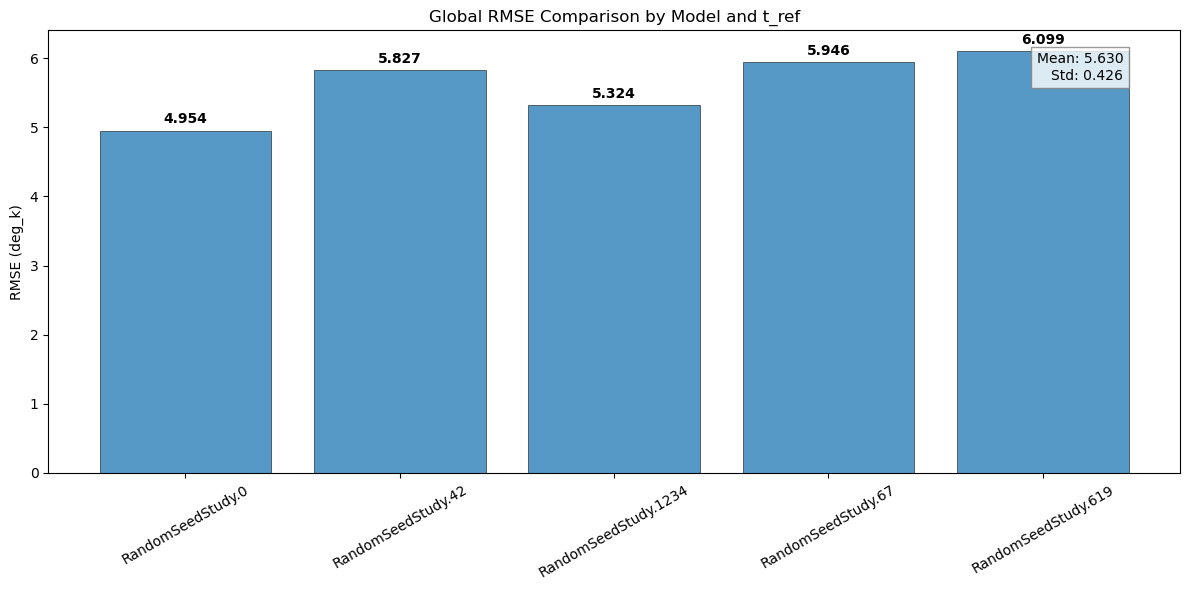

In [3]:
Model_results.plot_global_RMSE('t_ref', output_statics=True)